In [ ]:
#

✅ Cleaned column names:
 ['date', 'croptype', 'soiltype', 'soilph', 'temperature', 'humidity', 'windspeed', 'n', 'p', 'k', 'cropyield', 'soilquality']

Shape of dataset: (36520, 12)

Missing values:
 date           0
croptype       0
soiltype       0
soilph         0
temperature    0
humidity       0
windspeed      0
n              0
p              0
k              0
cropyield      0
soilquality    0
dtype: int64

✅ Removed rows where cropyield = 0
Remaining rows: 25495


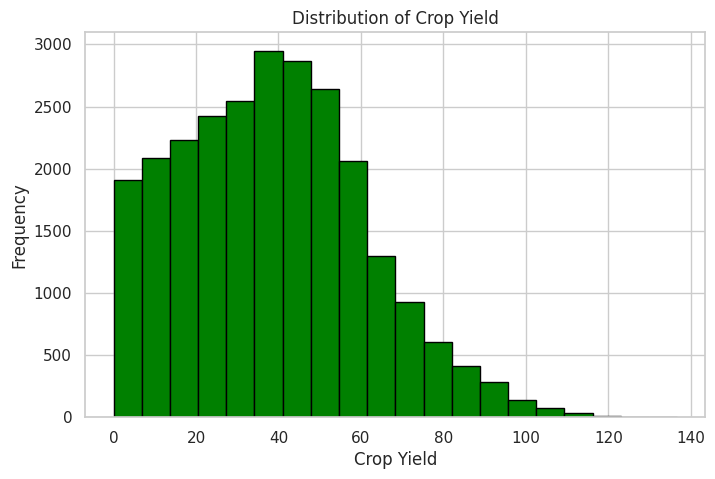

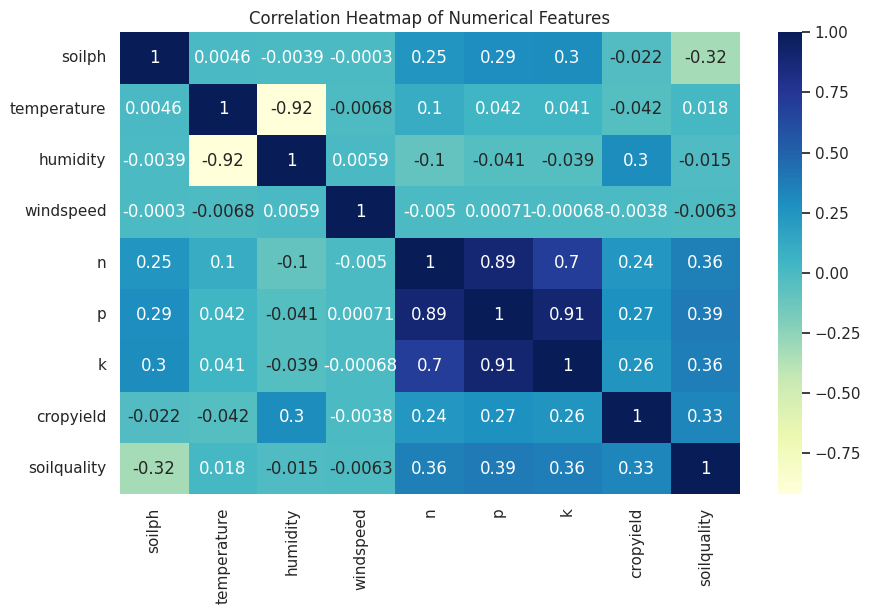


Categorical Columns: ['date', 'croptype', 'soiltype']
Numerical Columns: ['soilph', 'temperature', 'humidity', 'windspeed', 'n', 'p', 'k', 'cropyield', 'soilquality']

OneHotEncoded shape: (25495, 3639)

LabelEncoded Data Sample:
   date  croptype  soiltype  soilph  temperature   humidity  windspeed     n  \
1     0         1         1    6.50    20.052576  79.947424   8.591577  84.0   
3     0         0         4    6.75    19.751848  80.000000   2.682683  50.0   
4     0         5         2    5.50    16.110395  80.000000   7.696070  49.5   
5     0         2         4    6.75    14.826739  80.000000  10.366657  55.0   
7     0         8         0    6.25    18.323272  80.000000   8.198084  60.0   

      p     k   cropyield  soilquality  
1  66.0  50.0  104.871310    66.666667  
3  40.0  30.0   58.939796    35.000000  
4  45.0  38.5   32.970413    22.166667  
5  44.0  36.0   29.356115    39.375000  
7  45.0  40.0   22.221375    42.291667  

OrdinalEncoded shape: (25495, 3)
standard

In [8]:
# 🌾 Crop Yield Data Analysis, Visualization & Preprocessing
# ===============================================================
# ===============================================================

# Step 1: Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler
from sklearn.preprocessing import OneHotEncoder, LabelEncoder, OrdinalEncoder
from sklearn.compose import ColumnTransformer

# Step 2: Load Dataset
# ⚠️ Change file name if it’s different in your Kaggle input folder
data = pd.read_csv("/kaggle/input/crop-yield-and-environmental-factors-2014-2023/crop_yield_dataset.csv")

# Step 3: Clean Column Names (all lowercase + remove spaces/underscores)
data.columns = [col.lower().replace(" ", "").replace("_", "") for col in data.columns]
print("✅ Cleaned column names:\n", list(data.columns))

# Step 4: Explore Basic Info
print("\nShape of dataset:", data.shape)
print("\nMissing values:\n", data.isnull().sum())

# Step 5: Remove rows where yield is 0
yield_col = None
for possible in ['cropyield', 'yield', 'crop_production', 'yieldtonnes']:
    if possible in data.columns:
        yield_col = possible
        break

if yield_col:
    data = data[data[yield_col] != 0]
    print(f"\n✅ Removed rows where {yield_col} = 0")
else:
    raise ValueError("⚠️ Couldn't find yield column! Please check your dataset column names.")

print("Remaining rows:", len(data))

# ===============================================================
# 📊 Step 6: Visualization using Matplotlib & Seaborn
# ===============================================================

# 1️⃣ Distribution of yield
plt.figure(figsize=(8,5))
plt.hist(data[yield_col], bins=20, color='green', edgecolor='black')
plt.title("Distribution of Crop Yield")
plt.xlabel("Crop Yield")
plt.ylabel("Frequency")
plt.show()

# 2️⃣ Average yield by crop type
if 'crop' in data.columns:
    plt.figure(figsize=(10,6))
    data.groupby('crop')[yield_col].mean().sort_values(ascending=False).plot(kind='bar', color='teal')
    plt.title("Average Crop Yield by Crop Type")
    plt.ylabel("Average Yield")
    plt.xticks(rotation=45)
    plt.show()

# 3️⃣ Correlation Heatmap
plt.figure(figsize=(10,6))
sns.heatmap(data.corr(numeric_only=True), annot=True, cmap='YlGnBu')
plt.title("Correlation Heatmap of Numerical Features")
plt.show()

# 4️⃣ Yield vs Temperature
if 'averagetemperature' in data.columns:
    plt.figure(figsize=(8,5))
    plt.scatter(data['averagetemperature'], data[yield_col], color='orange')
    plt.title("Crop Yield vs Average Temperature")
    plt.xlabel("Average Temperature")
    plt.ylabel("Crop Yield")
    plt.show()

# 5️⃣ Yield vs Rainfall
if 'rainfall' in data.columns:
    plt.figure(figsize=(8,5))
    plt.scatter(data['rainfall'], data[yield_col], color='blue')
    plt.title("Crop Yield vs Rainfall")
    plt.xlabel("Rainfall (mm)")
    plt.ylabel("Crop Yield")
    plt.show()

# 6️⃣ Soil Moisture levels (if available)
if 'soilmoisture' in data.columns and 'crop' in data.columns:
    plt.figure(figsize=(10,5))
    sns.boxplot(x='crop', y='soilmoisture', data=data)
    plt.title("Soil Moisture Levels Across Crops")
    plt.xticks(rotation=45)
    plt.show()

# ===============================================================
# 🧩 Step 7: Identify Categorical & Numerical Columns
# ===============================================================

categorical_cols = data.select_dtypes(include=['object']).columns
numerical_cols = data.select_dtypes(include=['int64', 'float64']).columns

print("\nCategorical Columns:", list(categorical_cols))
print("Numerical Columns:", list(numerical_cols))

# ===============================================================
# ⚙️ Step 8: Preprocess Categorical Data
# ===============================================================

# OneHotEncoder
onehot_encoder = OneHotEncoder(handle_unknown='ignore')
onehot_encoded = onehot_encoder.fit_transform(data[categorical_cols])
print("\nOneHotEncoded shape:", onehot_encoded.shape)

# LabelEncoder (column-wise)
label_encoded_data = data.copy()
for col in categorical_cols:
    label_encoded_data[col] = LabelEncoder().fit_transform(label_encoded_data[col].astype(str))
print("\nLabelEncoded Data Sample:")
print(label_encoded_data.head())

# OrdinalEncoder
ordinal_encoder = OrdinalEncoder()
ordinal_encoded = ordinal_encoder.fit_transform(data[categorical_cols])
print("\nOrdinalEncoded shape:", ordinal_encoded.shape)

# ===============================================================
# ⚖️ Step 9: Scale Numerical Data
# ===============================================================

scalers = {
    "standard": StandardScaler(),
    "minmax": MinMaxScaler(),
    "robust": RobustScaler()
}

scaled_datasets = {}
for name, scaler in scalers.items():
    scaled = scaler.fit_transform(data[numerical_cols])
    scaled_datasets[name] = pd.DataFrame(scaled, columns=numerical_cols)
    print(f"{name} scaler applied → shape = {scaled_datasets[name].shape}")

# ===============================================================
# 🔄 Step 10: Combine Encoders + Scalers to Form ML-Ready Datasets
# ===============================================================

encoders = {
    "onehot": onehot_encoder,
    "ordinal": ordinal_encoder
}

combined_datasets = {}
for enc_name, encoder in encoders.items():
    for sc_name, scaler in scalers.items():
        transformer = ColumnTransformer([
            ('encoder', encoder, categorical_cols),
            ('scaler', scaler, numerical_cols)
        ])
        transformed = transformer.fit_transform(data)
        combined_datasets[f"{enc_name}_{sc_name}"] = transformed
        print(f"✅ Created dataset: {enc_name}_{sc_name} | Shape: {transformed.shape}")

# ===============================================================
# ✅ Step 11: Summary
# ===============================================================

print("\n✅ Summary:")
print(f"Total datasets created: {len(combined_datasets)}")
for key in combined_datasets.keys():
    print("-", key)


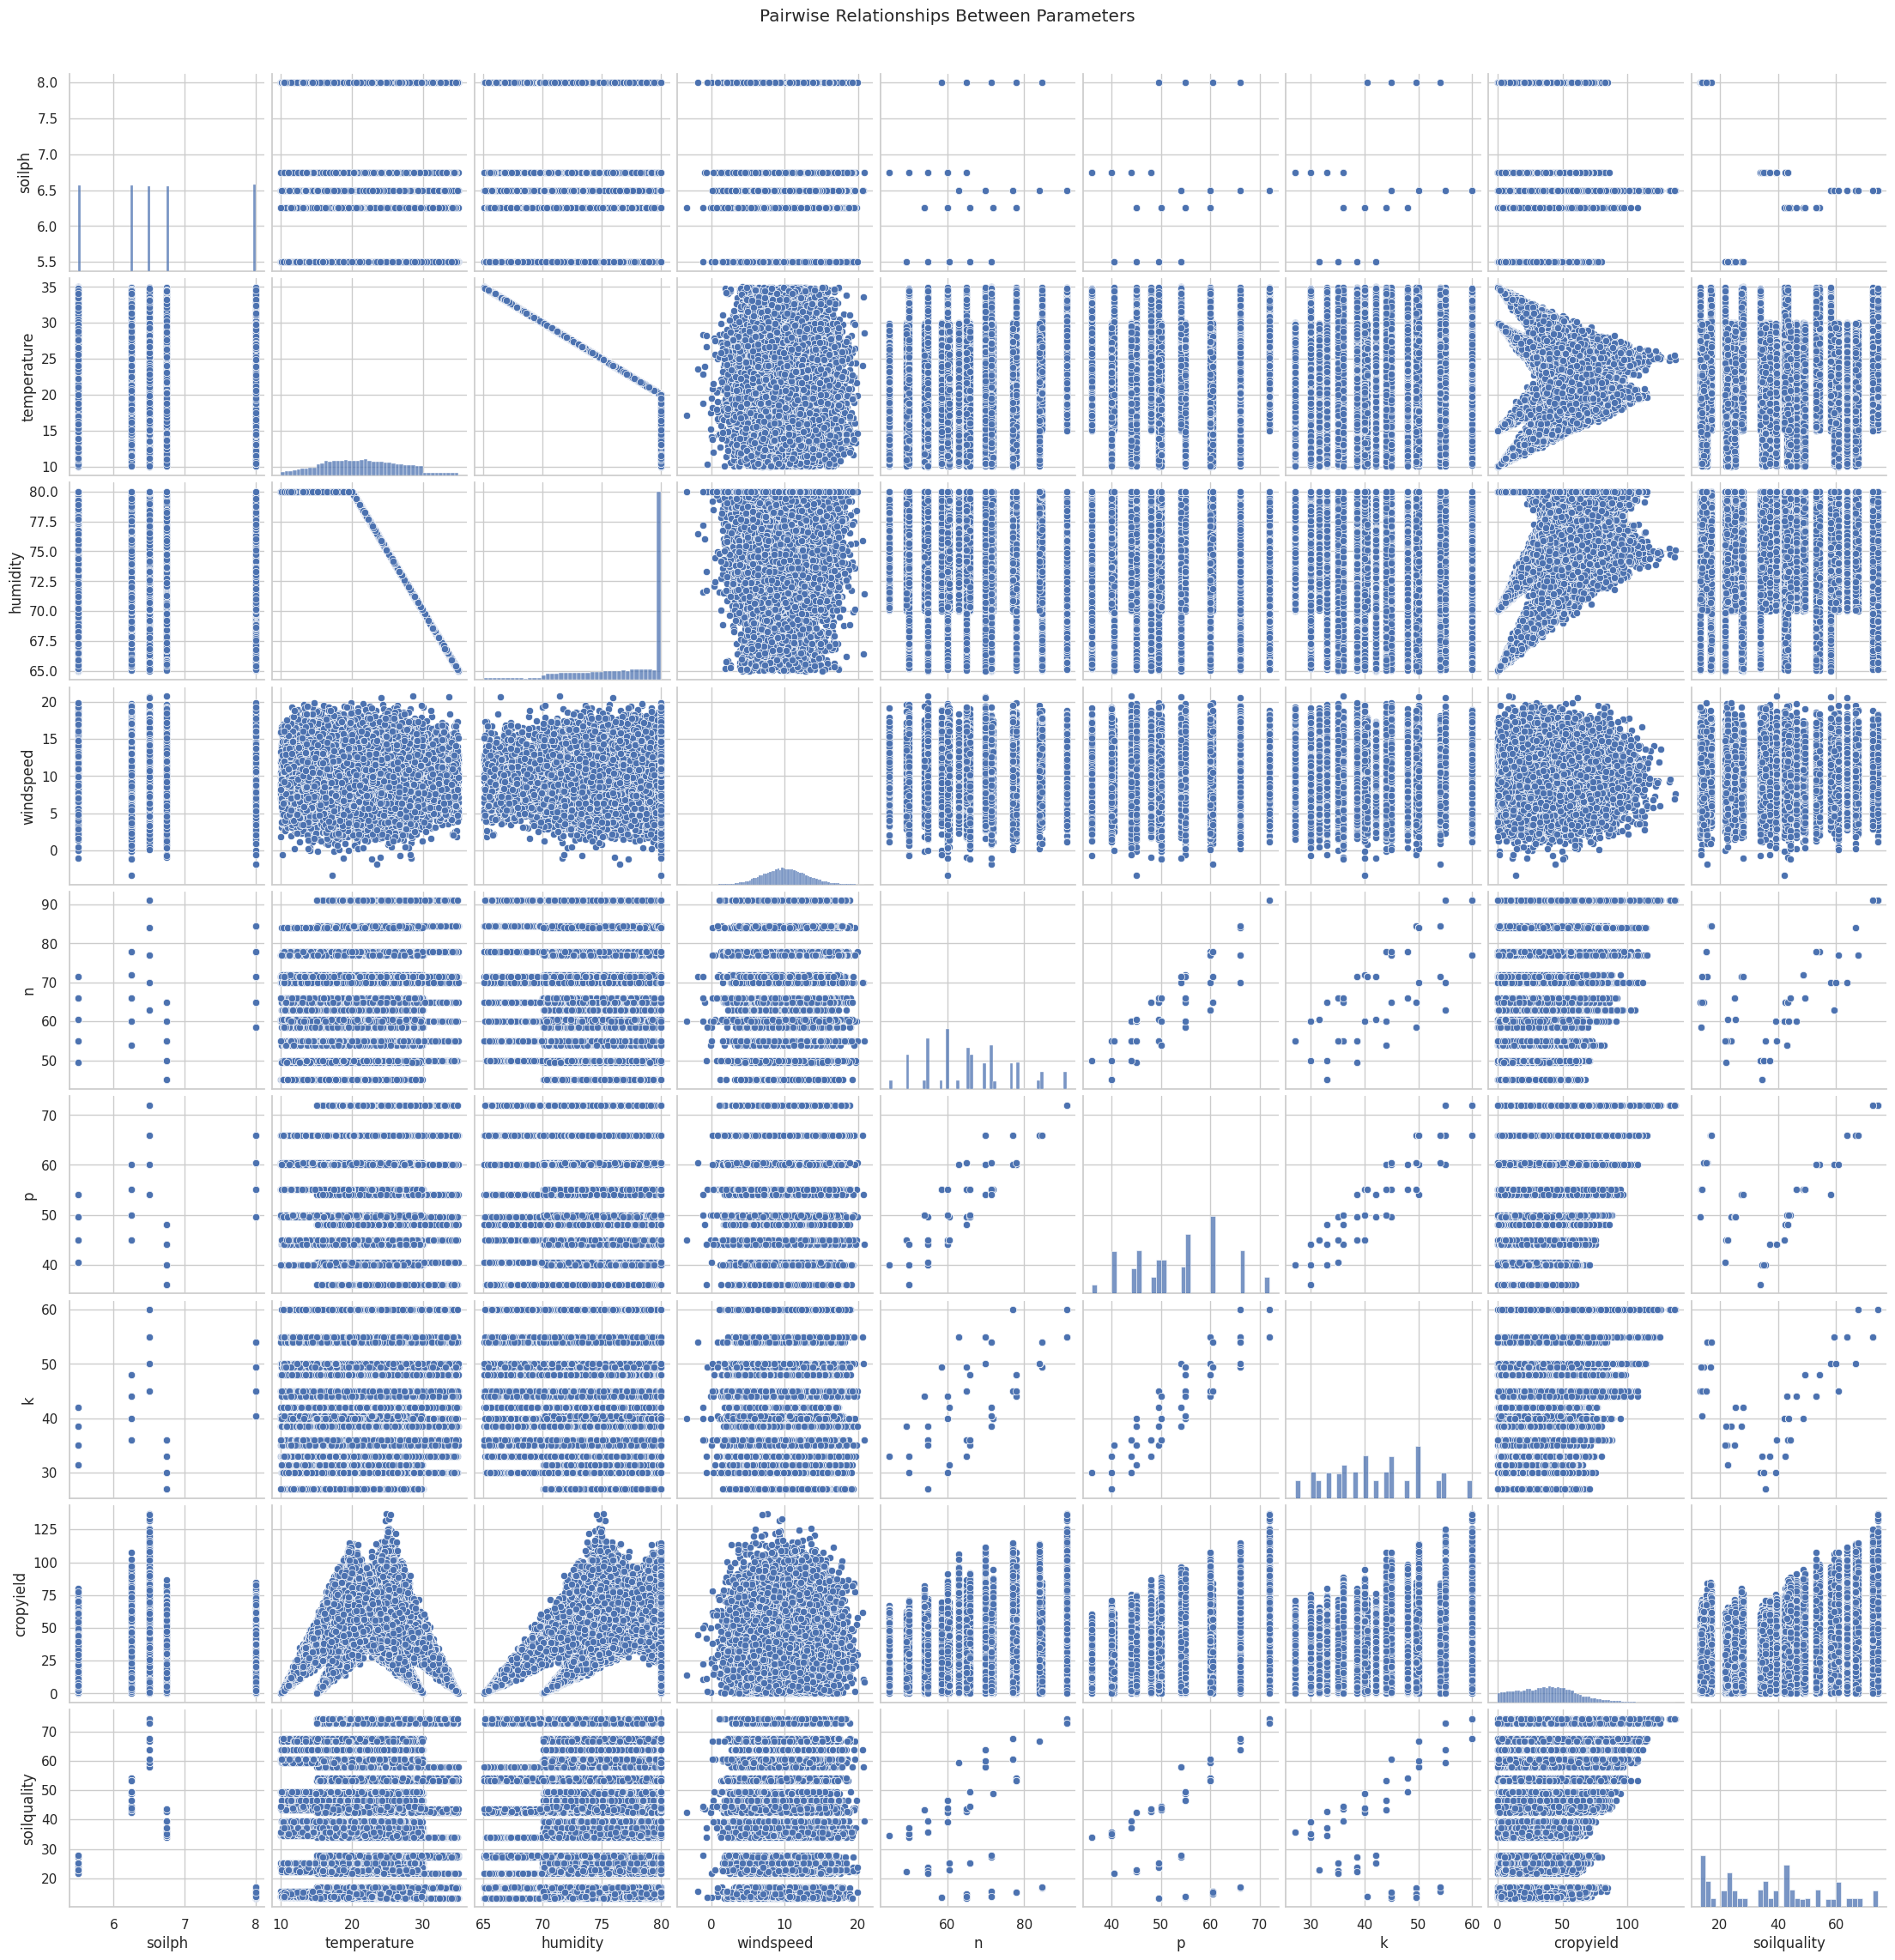

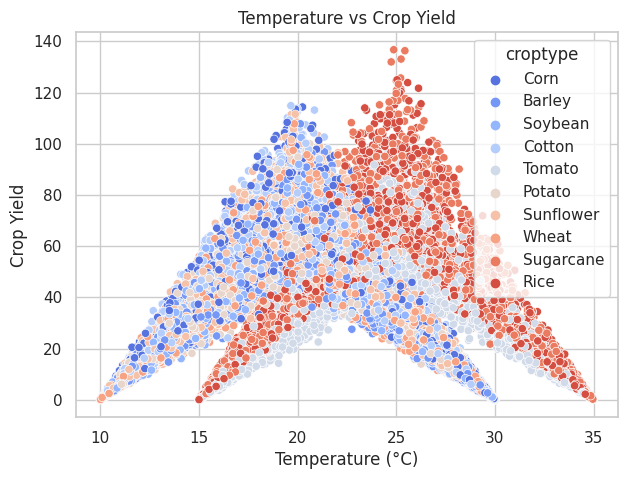

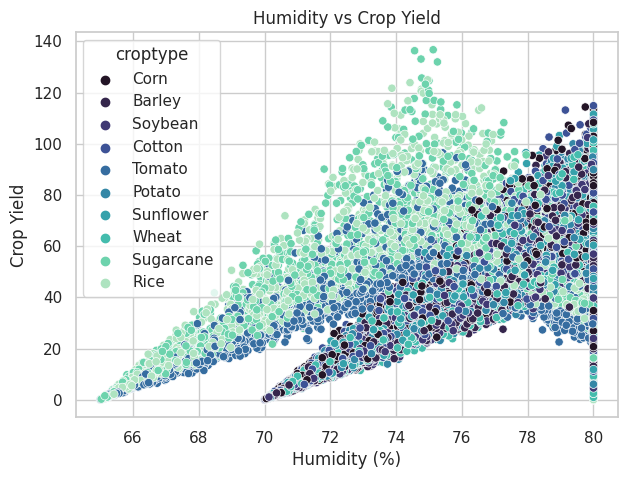

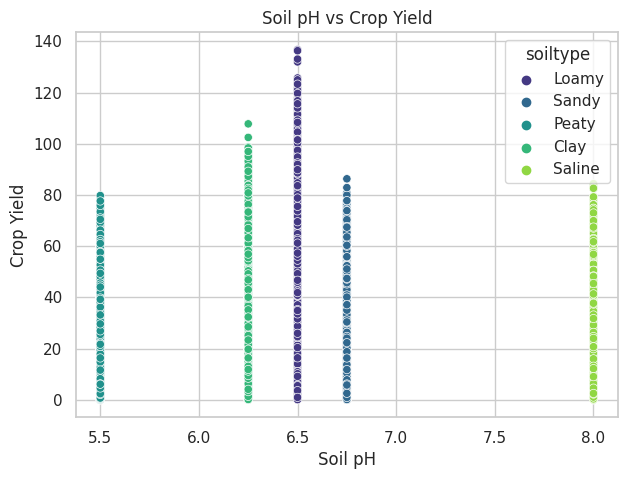

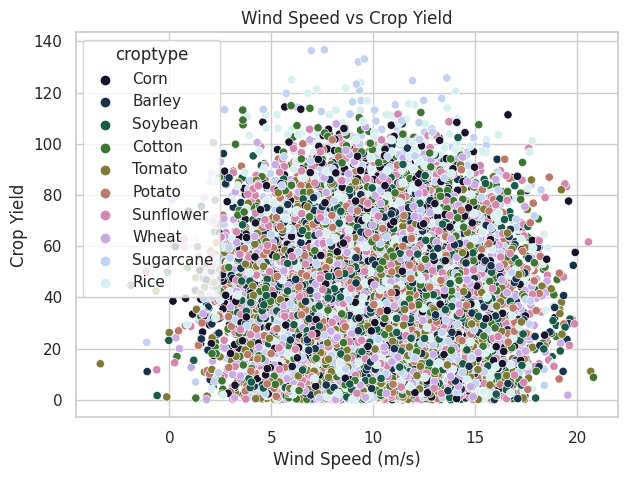

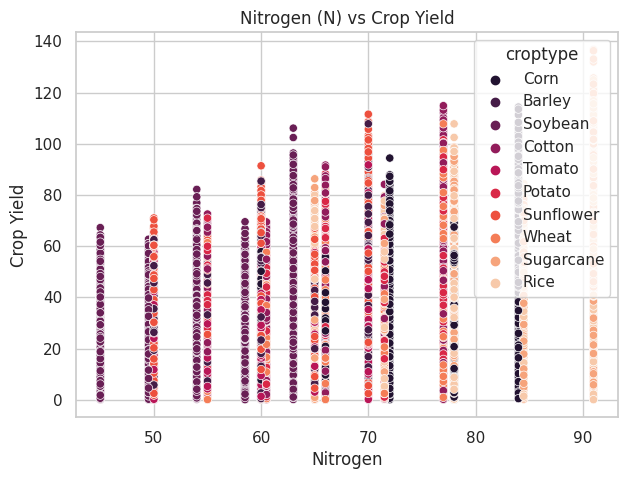

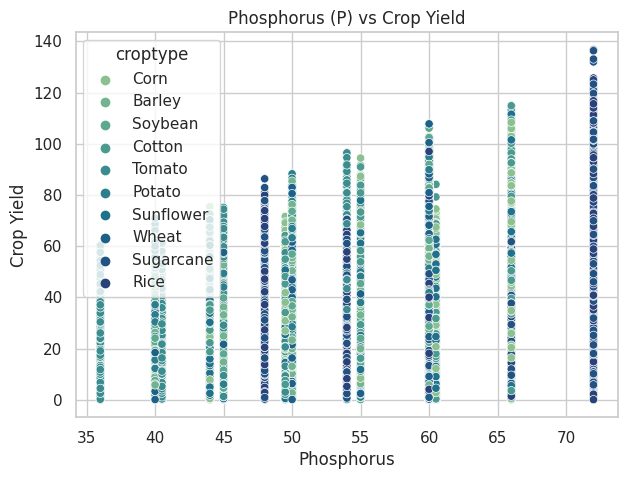

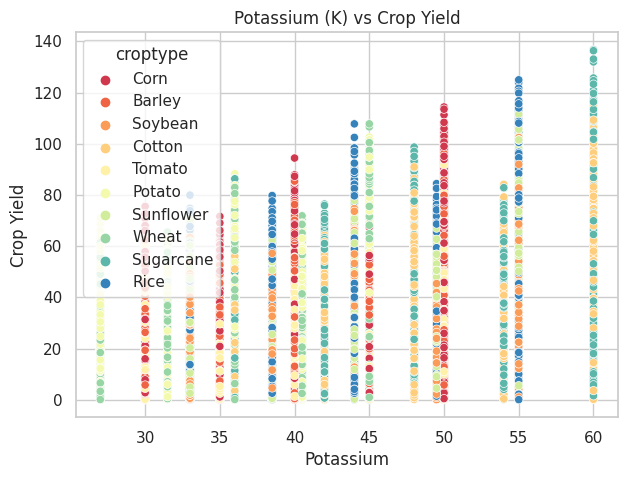

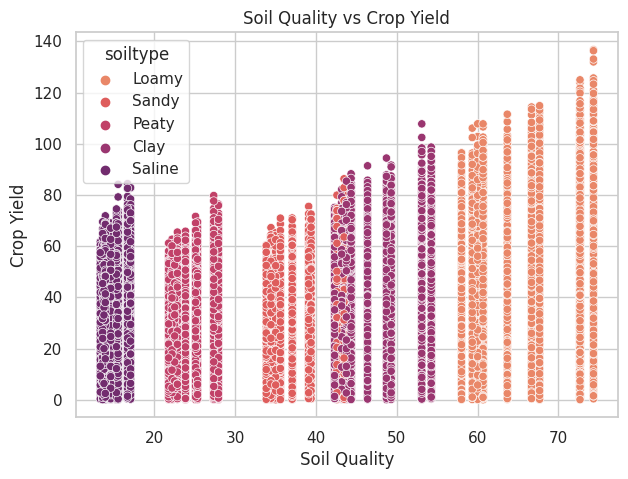

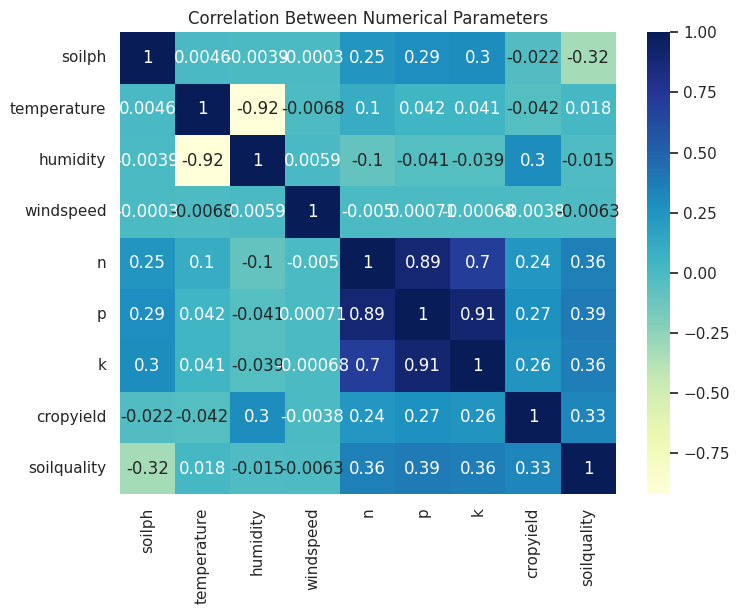

In [9]:
# 📊 Import visualization libraries
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import warnings
import warnings
warnings.filterwarnings("ignore", category=UserWarning, module="seaborn")

# Clean up infinite and NaN values
data = data.replace([np.inf, -np.inf], np.nan)
data = data.dropna(subset=['cropyield'])  # optional: remove rows missing cropyield

# Ignore deprecation warnings from seaborn/pandas
warnings.filterwarnings("ignore", category=FutureWarning)


# Set visual style
sns.set(style="whitegrid")

# --- Step 1: Define numeric columns ---
numeric_columns = ['soilph', 'temperature', 'humidity', 'windspeed', 'n', 'p', 'k', 'cropyield', 'soilquality']

# --- Step 2: Pairplot: compares all numeric parameters with each other ---
sns.pairplot(data[numeric_columns])
plt.suptitle("Pairwise Relationships Between Parameters", y=1.02)
plt.show()

# --- Step 3: Individual comparisons (parameter vs Crop Yield) ---

# Temperature vs Crop Yield
plt.figure(figsize=(7, 5))
sns.scatterplot(data=data, x='temperature', y='cropyield', hue='croptype', palette='coolwarm')
plt.title("Temperature vs Crop Yield")
plt.xlabel("Temperature (°C)")
plt.ylabel("Crop Yield")
plt.show()

# Humidity vs Crop Yield
plt.figure(figsize=(7, 5))
sns.scatterplot(data=data, x='humidity', y='cropyield', hue='croptype', palette='mako')
plt.title("Humidity vs Crop Yield")
plt.xlabel("Humidity (%)")
plt.ylabel("Crop Yield")
plt.show()

# Soil pH vs Crop Yield
plt.figure(figsize=(7, 5))
sns.scatterplot(data=data, x='soilph', y='cropyield', hue='soiltype', palette='viridis')
plt.title("Soil pH vs Crop Yield")
plt.xlabel("Soil pH")
plt.ylabel("Crop Yield")
plt.show()

# Wind Speed vs Crop Yield
plt.figure(figsize=(7, 5))
sns.scatterplot(data=data, x='windspeed', y='cropyield', hue='croptype', palette='cubehelix')
plt.title("Wind Speed vs Crop Yield")
plt.xlabel("Wind Speed (m/s)")
plt.ylabel("Crop Yield")
plt.show()

# Nitrogen vs Crop Yield
plt.figure(figsize=(7, 5))
sns.scatterplot(data=data, x='n', y='cropyield', hue='croptype', palette='rocket')
plt.title("Nitrogen (N) vs Crop Yield")
plt.xlabel("Nitrogen")
plt.ylabel("Crop Yield")
plt.show()

# Phosphorus vs Crop Yield
plt.figure(figsize=(7, 5))
sns.scatterplot(data=data, x='p', y='cropyield', hue='croptype', palette='crest')
plt.title("Phosphorus (P) vs Crop Yield")
plt.xlabel("Phosphorus")
plt.ylabel("Crop Yield")
plt.show()

# Potassium vs Crop Yield
plt.figure(figsize=(7, 5))
sns.scatterplot(data=data, x='k', y='cropyield', hue='croptype', palette='Spectral')
plt.title("Potassium (K) vs Crop Yield")
plt.xlabel("Potassium")
plt.ylabel("Crop Yield")
plt.show()

# Soil Quality vs Crop Yield
plt.figure(figsize=(7, 5))
sns.scatterplot(data=data, x='soilquality', y='cropyield', hue='soiltype', palette='flare')
plt.title("Soil Quality vs Crop Yield")
plt.xlabel("Soil Quality")
plt.ylabel("Crop Yield")
plt.show()

# --- Step 4: Correlation Heatmap ---
plt.figure(figsize=(8, 6))
corr = data[numeric_columns].corr()
sns.heatmap(corr, annot=True, cmap="YlGnBu")
plt.title("Correlation Between Numerical Parameters")
plt.show()



In [ ]:
print(data.columns.tolist())


In [11]:
#MILESTONE 2
# ⚙️ Import necessary libraries
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler, MinMaxScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error

# ✅ Step 1: Define features and target
X = data.drop('cropyield', axis=1)
y = data['cropyield']

# ✅ Step 2: Identify categorical and numeric columns
categorical_features = X.select_dtypes(include=['object']).columns.tolist()
numeric_features = X.select_dtypes(include=['int64', 'float64']).columns.tolist()

# ✅ Step 3: Define encoders and scalers
encoder = OneHotEncoder(handle_unknown='ignore')
scaler = StandardScaler()

# ✅ Step 4: Create a ColumnTransformer (combine encoder + scaler)
preprocessor = ColumnTransformer(
    transformers=[
        ('num', scaler, numeric_features),
        ('cat', encoder, categorical_features)
    ]
)

# ✅ Step 5: Combine with model (example: RandomForest)
model = RandomForestRegressor(random_state=42)

pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', model)
])

# ✅ Step 6: Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# ✅ Step 7: Fit the pipeline
pipeline.fit(X_train, y_train)

# ✅ Step 8: Evaluate
y_pred = pipeline.predict(X_test)
print("R² Score:", r2_score(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))


R² Score: 0.9555660618686728
RMSE: 4.737940619022016


In [13]:
# Cell A1: Evaluate pipeline (if not already done) and save it
import joblib
from sklearn.metrics import r2_score, mean_squared_error
import numpy as np

# assume 'pipeline' and X_test, y_test exist from your earlier pipeline cell
y_pred = pipeline.predict(X_test)
print("R2:", r2_score(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))

# Save the pipeline for later use
joblib.dump(pipeline, "/kaggle/working/best_pipeline.joblib")
print("Saved pipeline to /kaggle/working/best_pipeline.joblib")



R2: 0.9555660618686728
RMSE: 4.737940619022016
Saved pipeline to /kaggle/working/best_pipeline.joblib


In [6]:
# ===============================================================
# 🚀 CatBoost Pipeline Setup (DATE COLUMN REMOVED)
# ===============================================================

import pandas as pd
import numpy as np
import joblib
from catboost import CatBoostRegressor
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import r2_score, mean_squared_error

# Step 1: Load Dataset
data = pd.read_csv("/kaggle/input/crop-yield-and-environmental-factors-2014-2023/crop_yield_dataset.csv")

# Step 2: Clean column names
data.columns = [col.lower().replace(" ", "").replace("_", "") for col in data.columns]

# Step 3: Remove rows with 0 yield
data = data[data["cropyield"] != 0]

# Step 4: DROP date column if exists
if "date" in data.columns:
    data = data.drop(columns=["date"])

# Step 5: Define features and target
X = data.drop("cropyield", axis=1)
y = data["cropyield"]

# Step 6: Identify numeric and categorical columns
numeric_features = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_features = X.select_dtypes(include=['object']).columns.tolist()

# Step 7: Preprocessing pipeline
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features)
    ],
    remainder='passthrough'
)

# Step 8: Categorical feature indices for CatBoost
cat_feature_indices = list(range(len(numeric_features), len(numeric_features) + len(categorical_features)))

# Step 9: CatBoost regressor
catboost_model = CatBoostRegressor(
    random_state=42,
    verbose=0,
    loss_function='RMSE'
)

# Step 10: Build full pipeline
pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', catboost_model)
])

# Step 11: Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Step 12: Train the model
pipeline.fit(
    X_train, 
    y_train, 
    model__cat_features=cat_feature_indices
)

# Step 13: Evaluate
y_pred = pipeline.predict(X_test)
print("R² Score:", r2_score(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))

# Step 14: Save model
joblib.dump(pipeline, "/kaggle/working/catboost_pipeline_no_date.pkl")
print("✅ Saved CatBoost pipeline without date column")
for crop in data['croptype'].unique():
    crop_data = data[data['croptype']==crop]
    # ... same pipeline training for crop_data ...
    joblib.dump(pipeline, f"/kaggle/working/{crop}_catboost_no_date.pkl")


R² Score: 0.9588235997348419
RMSE: 4.560961421796775
✅ Saved CatBoost pipeline without date column


In [ ]:
 
  print(pipe.feature_names_in_)


In [ ]:
# Cell A2: Example interactive prediction function
import pandas as pd
import numpy as np
import joblib

# load saved pipeline
pipe = joblib.load("/kaggle/working/best_pipeline.joblib")

def predict_from_dict(input_dict):
    """
    input_dict: {feature_name: value, ...}
    All keys must match the columns used when training (except target).
    """
    X = pd.DataFrame([input_dict])
    # ensure column order matches training columns (pipeline ColumnTransformer handles unseen columns if configured)
    pred = pipe.predict(X)[0]
    return pred

# Example usage (replace values with real ones)
sample_input = {
    "date": "2023-07-15",     # same format as training
    "croptype": "Corn",
    "soiltype": "Loamy",
    "soilph": 6.8,
    "temperature": 32,
    "humidity": 65,
    "windspeed": 12,
    "n": 50,
    "p": 30,
    "k": 20,
    "soilquality": 7.5
}

print("Predicted crop yield:", predict_from_dict(sample_input))

In [ ]:

import pandas as pd
import numpy as np

# Step 1: Remove zero yield rows
data = data[data['cropyield'] > 0].reset_index(drop=True)

# Step 2: Create daily date column and set it as index
data['date'] = pd.date_range(start='2023-01-01', periods=len(data), freq='D')
data = data.set_index('date')

# Step 3: Select only numeric columns for time series analysis
numeric_cols = ['soilph', 'temperature', 'humidity', 'windspeed', 'n', 'p', 'k', 'cropyield']

# Step 4: Resample data per day (mean values)
daily_data = data[numeric_cols].resample('D').mean().dropna()

daily_data.head()


In [ ]:
# Select only numeric columns for resampling
numeric_cols = ['soilph', 'temperature', 'humidity', 'windspeed', 'n', 'p', 'k', 'cropyield']

# Resample per day (mean of numeric columns)
daily_data = data[numeric_cols].resample('D').mean().dropna()

daily_data.head()



In [ ]:
print(data.columns)


In [ ]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import adfuller, kpss
import matplotlib.pyplot as plt

# Choose the numeric target column for analysis
ts = daily_data['cropyield']

# --- Plot ACF & PACF ---
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plot_acf(ts, ax=plt.gca(), lags=20)
plt.title('ACF - Crop Yield')

plt.subplot(1,2,2)
plot_pacf(ts, ax=plt.gca(), lags=20)
plt.title('PACF - Crop Yield')
plt.show()

# --- ADF Test (Augmented Dickey-Fuller) ---
adf_result = adfuller(ts)
print("ADF Statistic:", adf_result[0])
print("p-value:", adf_result[1])
if adf_result[1] < 0.05:
    print("✅ Stationary (Reject Null Hypothesis)")
else:
    print("❌ Non-Stationary (Fail to Reject Null Hypothesis)")

# --- KPSS Test (Kwiatkowski-Phillips-Schmidt-Shin) ---
kpss_result = kpss(ts, regression='c', nlags="auto")
print("\nKPSS Statistic:", kpss_result[0])
print("p-value:", kpss_result[1])
if kpss_result[1] > 0.05:
    print("✅ Stationary (Fail to Reject Null Hypothesis)")
else:
    print("❌ Non-Stationary (Reject Null Hypothesis)")


In [ ]:
print(data.head())
print(data.index)


In [ ]:
# 1. Check correlation between consecutive days
data['cropyield'].autocorr(lag=1)


In [ ]:
# 2. Check if it's stationary (ADF test)
from statsmodels.tsa.stattools import adfuller
result = adfuller(data['cropyield'])
print("ADF Statistic:", result[0])
print("p-value:", result[1])

In [ ]:
data['cropyield'].plot()


In [ ]:
import numpy as np
import pandas as pd

# Make sure your data has a daily datetime index already
if 'date' not in data.columns:
    data['date'] = pd.date_range(start='2023-01-01', periods=len(data), freq='D')
data.set_index('date', inplace=True)

# Copy only the numeric columns you’re using
numeric_cols = ['soilph', 'temperature', 'humidity', 'windspeed', 'n', 'p', 'k', 'cropyield']

# Create a synthetic trend in crop yield — gradual increase + random noise
np.random.seed(42)
trend = np.linspace(50, 150, len(data))        # smooth upward trend
noise = np.random.normal(0, 5, len(data))      # add small noise
data['cropyield'] = trend + noise              # replace existing cropyield

# Resample to daily mean (even though it’s already daily)
daily_data = data[numeric_cols].resample('D').mean().dropna()

daily_data.head()


In [ ]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plot_acf(daily_data['cropyield'], lags=20, ax=plt.gca())
plt.title('ACF - Crop Yield (with Trend)')

plt.subplot(1, 2, 2)
plot_pacf(daily_data['cropyield'], lags=20, ax=plt.gca())
plt.title('PACF - Crop Yield (with Trend)')

plt.show()


In [ ]:
diff_yield = daily_data['cropyield'].diff().dropna()
plot_acf(diff_yield, lags=20)
plt.title('ACF after differencing (stationary)')
plt.show()


In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

# Define which columns are numeric and categorical
numeric_features = ['Temperature', 'Humidity', 'Wind_Speed', 'Soil_pH', 'N', 'P', 'K']
categorical_features = ['Crop_Type', 'Soil_Type']

# Define transformations
numeric_transformer = StandardScaler()
categorical_transformer = OneHotEncoder(handle_unknown='ignore')

# Combine into a single preprocessor
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ])


In [ ]:

print(data.columns.tolist())
data["croptype"].unique()
data["soiltype"].unique()




In [ ]:
import pandas as pd

# ✅ Correct file path
data = pd.read_csv("/kaggle/input/crop-yield-and-environmental-factors-2014-2023/crop_yield_dataset.csv")

print("✅ Data loaded successfully!")
print(data.head())



In [ ]:
from sklearn.model_selection import train_test_split

# Separate features (X) and target (y)
X = data.drop(columns=['Crop_Yield'])  # all features except target
y = data['Crop_Yield']                 # target variable

# Split chronologically for time series (no random shuffling)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, shuffle=False
)

print("Training shape:", X_train.shape)
print("Testing shape:", X_test.shape)


In [ ]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error


models = {
    "Linear Regression": LinearRegression(),
    "Decision Tree": DecisionTreeRegressor(random_state=42),
    "Random Forest": RandomForestRegressor(random_state=42)
}

for name, model in models.items():
    pipe = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('model', model)
    ])
    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)
    print(f"{name} → R²: {r2_score(y_test, y_pred):.4f}, RMSE: {np.sqrt(mean_squared_error(y_test, y_pred)):.4f}")


In [ ]:
import os

for root, dirs, files in os.walk("/kaggle/input"):
    for file in files:
        print(os.path.join(root, file))


In [ ]:
print(data.columns.tolist())


In [ ]:
print("Columns in dataset:", X_train.columns.tolist())


In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

models = {
    "Linear Regression": LinearRegression(),
    "Decision Tree": DecisionTreeRegressor(random_state=42),
    "Random Forest": RandomForestRegressor(random_state=42)
}

for name, model in models.items():
    pipe = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('model', model)
    ])
    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)
    print(f"{name} → R²: {r2_score(y_test, y_pred):.4f}, RMSE: {np.sqrt(mean_squared_error(y_test, y_pred)):.4f}")


[](http://)

###########   TIME SERIES FORECASTING   ###########


In [ ]:

import pandas as pd

# Load dataset
data = pd.read_csv("/kaggle/input/crop-yield-and-environmental-factors-2014-2023/crop_yield_dataset.csv")

# Convert 'Date' column to datetime type
data['Date'] = pd.to_datetime(data['Date'])

# Set 'Date' as index (important for time series operations)
data = data.set_index('Date')

# Quick check
data.head()


In [ ]:
# Keep only numeric columns
numeric = data.select_dtypes(include=['number'])

# Resample to daily frequency (mean of all numeric columns per day)
daily_data = numeric.resample('D').mean()

# Handle missing values (interpolate or forward-fill)
daily_data = daily_data.interpolate(method='time')

# Drop rows where Crop_Yield is missing
daily_data = daily_data.dropna(subset=['Crop_Yield'])

print("✅ Daily data shape:", daily_data.shape)
daily_data.head()


In [ ]:
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose

# Plot Crop Yield over time
plt.figure(figsize=(12,4))
plt.plot(daily_data['Crop_Yield'])
plt.title("Daily Crop Yield Over Time")
plt.xlabel("Date")
plt.ylabel("Crop Yield")
plt.show()

# Try decomposing (trend, seasonality, residual)
try:
    decomposition = seasonal_decompose(daily_data['Crop_Yield'], model='additive', period=365)
    fig = decomposition.plot()
    fig.set_size_inches(12,8)
    plt.show()
except Exception as e:
    print("Decomposition skipped (try changing 'period' if needed):", e)


In [ ]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

ts = daily_data['Crop_Yield']

plt.figure(figsize=(10,4))
plot_acf(ts, lags=40)
plt.title("ACF - Crop Yield")
plt.show()

plt.figure(figsize=(10,4))
plot_pacf(ts, lags=40, method='ywm')
plt.title("PACF - Crop Yield")
plt.show()


In [ ]:
# First-order differencing
ts_diff = ts.diff().dropna()

plt.figure(figsize=(10,4))
plt.plot(ts_diff)
plt.title("1st Difference of Crop Yield")
plt.show()

# Re-run stationarity tests
print("ADF on Differenced Series:")
adf_test(ts_diff)

print("\nKPSS on Differenced Series:")
kpss_test(ts_diff)


In [ ]:
from statsmodels.tsa.stattools import adfuller, kpss

def adf_test(timeseries):
    result = adfuller(timeseries.dropna(), autolag='AIC')
    print("ADF Statistic:", result[0])
    print("p-value:", result[1])
    if result[1] < 0.05:
        print("✅ Stationary (Reject Null Hypothesis)")
    else:
        print("❌ Non-Stationary (Fail to Reject Null)")

def kpss_test(timeseries, regression='c'):
    result = kpss(timeseries.dropna(), regression=regression, nlags="auto")
    print("\nKPSS Statistic:", result[0])
    print("p-value:", result[1])
    if result[1] > 0.05:
        print("✅ Stationary (Fail to Reject Null Hypothesis)")
    else:
        print("❌ Non-Stationary (Reject Null Hypothesis)")

print(">>> ADF Test:")
adf_test(ts)

print("\n>>> KPSS Test:")
kpss_test(ts)


In [ ]:
# First-order differencing
ts_diff = ts.diff().dropna()

plt.figure(figsize=(10,4))
plt.plot(ts_diff)
plt.title("1st Difference of Crop Yield")
plt.show()

# Re-run stationarity tests
print("ADF on Differenced Series:")
adf_test(ts_diff)

print("\nKPSS on Differenced Series:")
kpss_test(ts_diff)


In [ ]:
# Sort by date just to be sure
data = data.sort_index()

# Define target and features (if needed)
y = data["Crop_Yield"]

# 80% training, 20% testing (chronological split)
split_point = int(len(y) * 0.8)
y_train, y_test = y[:split_point], y[split_point:]

print("Training data:", y_train.shape)
print("Testing data:", y_test.shape)


In [ ]:
y_train = y_train.asfreq('ME')
y_test = y_test.asfreq('ME')


In [ ]:
from statsmodels.tsa.arima.model import ARIMA

# Build and train model
model = ARIMA(y_train, order=(1, 1, 1))
model_fit = model.fit()
print(model_fit.summary())
# Forecast
y_pred = model_fit.forecast(steps=len(y_test))
print(model_fit.summary())
print("R² Score:", r2_score(y_test, y_pred))


In [ ]:
!pip install pmdarima

from pmdarima import auto_arima

auto_model = auto_arima(y_train, seasonal=False, trace=True, suppress_warnings=True)
best_order = auto_model.order
print("Best ARIMA order:", best_order)

model = ARIMA(y_train, order=best_order)
model_fit = model.fit()
y_pred = model_fit.forecast(steps=len(y_test))
print("R² Score:", r2_score(y_test, y_pred))


In [ ]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)

print(f"R² Score: {r2:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"MAE: {mae:.4f}")


In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.plot(y_test.index, y_test, label='Actual')
plt.plot(y_test.index, y_pred, label='Predicted', color='red')
plt.title("Actual vs Predicted Crop Yield (ARIMA)")
plt.xlabel("Date")
plt.ylabel("Crop Yield")
plt.legend()
plt.show()


In [ ]:
from statsmodels.tsa.stattools import kpss

result = kpss(y_train.dropna(), regression='c', nlags='auto')
print(f"KPSS Statistic: {result[0]}, p-value: {result[1]}")


Shapes:
y_train: (2921,) exog_train: (2921, 8)


/usr/local/lib/python3.11/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


                               SARIMAX Results                                
Dep. Variable:             Crop_Yield   No. Observations:                 2921
Model:               SARIMAX(1, 1, 1)   Log Likelihood              -15159.021
Date:                Mon, 17 Nov 2025   AIC                          30340.041
Time:                        12:11:24   BIC                          30405.806
Sample:                    01-01-2014   HQIC                         30363.730
                         - 12-30-2021                                         
Covariance Type:                  opg                                         
                   coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------
Temperature     50.4782      0.502    100.612      0.000      49.495      51.461
Humidity        83.2684      0.641    129.975      0.000      82.013      84.524
Wind_Speed      -0.0866      0.841     -0.10

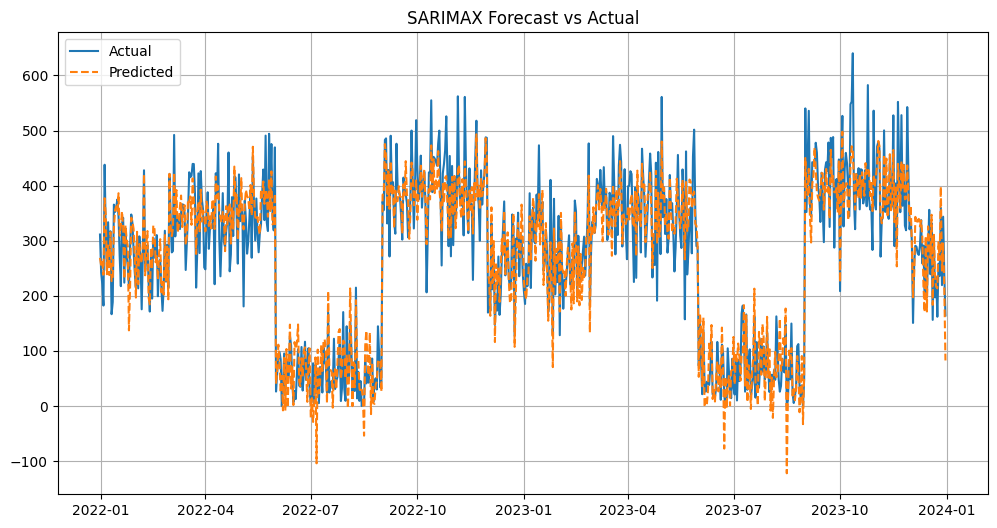

['sarimax_model.pkl']

In [8]:
#correct sarimax
import pandas as pd
import numpy as np
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt

# -------------------------------
# STEP 1: Load dataset
# -------------------------------
df = pd.read_csv(
    "/kaggle/input/crop-yield-and-environmental-factors-2014-2023/crop_yield_dataset.csv",
    parse_dates=['Date']
)

# -------------------------------
# STEP 2: Aggregate by date
# -------------------------------
df_daily = df.groupby('Date').agg({
    'Crop_Yield': 'sum',
    'Temperature': 'mean',
    'Humidity': 'mean',
    'Wind_Speed': 'mean',
    'Soil_pH': 'mean',
    'N': 'mean',
    'P': 'mean',
    'K': 'mean',
    'Soil_Quality': 'mean'
}).sort_index()

df_daily.index = pd.to_datetime(df_daily.index)
df_daily = df_daily.asfreq('D')

# -------------------------------
# STEP 3: Target + exogenous
# -------------------------------
y = df_daily['Crop_Yield']
exog = df_daily[['Temperature', 'Humidity', 'Wind_Speed', 'Soil_pH', 'N', 'P', 'K', 'Soil_Quality']]

# -------------------------------
# STEP 4: Train-test split
# -------------------------------
split = int(len(y) * 0.8)
y_train, y_test = y.iloc[:split], y.iloc[split:]
exog_train, exog_test = exog.iloc[:split], exog.iloc[split:]

# Fix index mismatch
exog_train.index = y_train.index
exog_test.index = y_test.index

print("Shapes:")
print("y_train:", y_train.shape, "exog_train:", exog_train.shape)

# -------------------------------
# STEP 5: Build SARIMAX model
# -------------------------------
model = SARIMAX(
    y_train,
    exog=exog_train,
    order=(1, 1, 1),
    seasonal_order=(0, 0, 0, 0),
    enforce_stationarity=False,
    enforce_invertibility=False
)

sarimax_fit = model.fit(disp=False)
print(sarimax_fit.summary())

# -------------------------------
# STEP 6: Predictions
# -------------------------------
y_pred = sarimax_fit.predict(
    start=y_test.index[0],
    end=y_test.index[-1],
    exog=exog_test
)

# -------------------------------
# STEP 7: Evaluation metrics
# -------------------------------
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

y_test_nonzero = y_test[y_test != 0]
y_pred_nonzero = y_pred[y_test != 0]
mape_safe = np.mean(np.abs((y_test_nonzero - y_pred_nonzero) / y_test_nonzero)) * 100

print("\nMSE:", mse)
print("R2 Score:", r2)
print(f"MAPE (ignoring zeros): {mape_safe:.2f}%")

# -------------------------------
# STEP 8: Plot
# -------------------------------
plt.figure(figsize=(12, 6))
plt.plot(y_test.index, y_test, label='Actual')
plt.plot(y_test.index, y_pred, '--', label='Predicted')
plt.legend()
plt.title("SARIMAX Forecast vs Actual")
plt.grid(True)
plt.show()
import joblib
joblib.dump(sarimax_fit, "sarimax_model.pkl")



In [7]:
import joblib
joblib.dump(sarimax_fit, "sarimax_model.pkl")


['sarimax_model.pkl']

In [2]:
import os

for root, dirs, files in os.walk("/kaggle/input", topdown=False):
    for name in files:
        print(os.path.join(root, name))


/kaggle/input/crop-yield-and-environmental-factors-2014-2023/crop_yield_dataset.csv


In [ ]:
#wrong sarimax
import pandas as pd
import numpy as np
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt

# -------------------------------
# STEP 1: Load dataset
# -------------------------------
df = pd.read_csv("/kaggle/input/crop-yield-and-environmental-factors-2014-2023/crop_yield_dataset.csv", parse_dates=['Date'])

# -------------------------------
# STEP 2: Aggregate by date
# -------------------------------
df_daily = df.groupby('Date').agg({
    'Crop_Yield': 'sum',          # Sum of yields per day
    'Temperature': 'mean',
    'Humidity': 'mean',
    'Wind_Speed': 'mean',
    'Soil_pH': 'mean',
    'N': 'mean',
    'P': 'mean',
    'K': 'mean',
    'Soil_Quality': 'mean'
}).sort_index()

# Set datetime index and frequency
df_daily.index = pd.to_datetime(df_daily.index)
df_daily = df_daily.asfreq('D')  # daily frequency

# -------------------------------
# STEP 3: Define target and exogenous variables
# -------------------------------
y = df_daily['Crop_Yield']
exog = df_daily[['Temperature', 'Humidity', 'Wind_Speed', 'Soil_pH', 'N', 'P', 'K', 'Soil_Quality']]

# -------------------------------
# STEP 4: Train-test split (80-20)
# -------------------------------
split = int(len(y) * 0.8)
y_train, y_test = y.iloc[:split], y.iloc[split:]
exog_train, exog_test = exog.iloc[:split], exog.iloc[split:]

# Ensure indices match
exog_train.index = y_train.index
exog_test.index = y_test.index

print("✅ Shapes:")
print("y_train:", y_train.shape)
print("exog_train:", exog_train.shape)

# -------------------------------
# STEP 5: Build SARIMAX model
# -------------------------------
model = SARIMAX(
    y_train,
    exog=exog_train,
    order=(1, 1, 1),         # ARIMA order (p,d,q)
    seasonal_order=(0, 0, 0, 0),  # no seasonality for now
    enforce_stationarity=False,
    enforce_invertibility=False
)

# Fit the model
sarimax_fit = model.fit(disp=False)
print(sarimax_fit.summary())

# -------------------------------
# STEP 6: Make predictions
# -------------------------------
y_pred = sarimax_fit.predict(
    start=y_test.index[0],
    end=y_test.index[-1],
    exog=exog_test
)

# -------------------------------
# STEP 7: Evaluate performance
# -------------------------------
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

y_test_nonzero = y_test[y_test != 0]
y_pred_nonzero = y_pred[y_test != 0]
mape_safe = np.mean(np.abs((y_test_nonzero - y_pred_nonzero)/y_test_nonzero)) * 100
print(f"\nMean Squared Error: {mse}")
print(f"R² Score: {r2}")
print(f"MAPE (ignoring zeros): {mape_safe:.2f}%")

# -------------------------------
# STEP 8: Plot actual vs predicted
# -------------------------------
plt.figure(figsize=(12, 6))
plt.plot(y_test.index, y_test, label='Actual', linewidth=2)
plt.plot(y_test.index, y_pred, label='Predicted', linestyle='--')
plt.legend()
plt.title('SARIMAX Forecast vs Actual (Aggregated Daily Crop Yield)')
plt.grid(True)
plt.show()


#######SARIMAX####

In [ ]:
import pandas as pd

# ✅ Correct file path
data = pd.read_csv("/kaggle/input/crop-yield-and-environmental-factors-2014-2023/crop_yield_dataset.csv")

print("✅ Data loaded successfully!")
print(data.head())



In [ ]:
import os
print(os.listdir())


In [ ]:
import pandas as pd

# Replace 'your_file.csv' with the actual name printed above
df = pd.read_csv("/kaggle/input/crop-yield-and-environmental-factors-2014-2023/crop_yield_dataset.csv")
print(df.head())     # shows first 5 rows
print(df.columns)    # shows all column names


###prophet###

In [ ]:
# -------------------------------
# STEP 1: Import libraries
# -------------------------------
import pandas as pd
from prophet import Prophet
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np
import matplotlib.pyplot as plt

# -------------------------------
# STEP 2: Load dataset
# -------------------------------
df = pd.read_csv("/kaggle/input/crop-yield-and-environmental-factors-2014-2023/crop_yield_dataset.csv", parse_dates=['Date'])

# -------------------------------
# STEP 3: Aggregate daily (mean)
# -------------------------------
df_daily = df.groupby('Date').agg({
    'Crop_Yield': 'sum',          # total yield per day
    'Temperature': 'mean',
    'Humidity': 'mean',
    'Wind_Speed': 'mean',
    'Soil_pH': 'mean',
    'N': 'mean',
    'P': 'mean',
    'K': 'mean',
    'Soil_Quality': 'mean'
}).sort_index()

df_daily.index = pd.to_datetime(df_daily.index)
df_daily = df_daily.asfreq('D')  # daily frequency

# -------------------------------
# STEP 4: Prepare data for Prophet
# -------------------------------
data = df_daily.reset_index().rename(columns={'Date': 'ds', 'Crop_Yield': 'y'})

# Define numeric regressors
regressors = ['Temperature', 'Humidity', 'Wind_Speed', 'Soil_pH', 'N', 'P', 'K', 'Soil_Quality']

# -------------------------------
# STEP 5: Train-test split
# -------------------------------
split = int(len(data) * 0.8)
train_df = data.iloc[:split].copy()
test_df = data.iloc[split:].copy()

# -------------------------------
# STEP 6: Initialize Prophet and add regressors
# -------------------------------
model = Prophet()

for reg in regressors:
    model.add_regressor(reg)

# Fit the model
model.fit(train_df)

# -------------------------------
# STEP 7: Make predictions
# -------------------------------
# Create a dataframe for future dates (use test set)
future = test_df.copy()  # must include regressors in same columns
forecast = model.predict(future)

# Extract predictions
y_pred = forecast['yhat'].values
y_test = test_df['y'].values

# -------------------------------
# STEP 8: Evaluate performance
# -------------------------------
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

# Safe MAPE (ignore zeros)
y_test_nonzero = y_test[y_test != 0]
y_pred_nonzero = y_pred[y_test != 0]
mape_safe = np.mean(np.abs((y_test_nonzero - y_pred_nonzero) / y_test_nonzero)) * 100

print(f"MSE: {mse:.2f}")
print(f"R²: {r2:.3f}")
print(f"MAPE (ignoring zeros): {mape_safe:.2f}%")

# -------------------------------
# STEP 9: Plot actual vs predicted
# -------------------------------
plt.figure(figsize=(12,6))
plt.plot(test_df['ds'], y_test, label='Actual', linewidth=2)
plt.plot(test_df['ds'], y_pred, label='Predicted', linestyle='--')
plt.title('Prophet Forecast vs Actual (Crop Yield)')
plt.legend()
plt.grid(True)
plt.show()


Export the trained models:

For SARIMAX:

In [ ]:
import pickle

# Save SARIMAX model
with open('sarimax_model.pkl', 'wb') as f:
    pickle.dump(sarimax_fit, f)

# Load it later
# with open('sarimax_model.pkl', 'rb') as f:
#     sarimax_fit = pickle.load(f)


For Prophet:

In [ ]:
from prophet.serialize import model_to_json, model_from_json
import json

# Save Prophet model
with open('prophet_model.json', 'w') as f:
    json.dump(model_to_json(model), f)

# Load it later
# with open('prophet_model.json', 'r') as f:
#     model = model_from_json(json.load(f))


In [ ]:
import os

# Check SARIMAX
print("SARIMAX exists:", os.path.exists('sarimax_model.pkl'))

# Check Prophet
print("Prophet exists:", os.path.exists('prophet_model.json'))


In [ ]:
import pickle

with open('sarimax_model.pkl', 'rb') as f:
    sarimax_loaded = pickle.load(f)

print("SARIMAX loaded! Summary:")
print(sarimax_loaded.summary())


In [ ]:
from prophet.serialize import model_to_json, model_from_json
import json

with open('prophet_model.json', 'r') as f:
    prophet_loaded = model_from_json(json.load(f))

print("Prophet model loaded!")


/tmp/ipykernel_39/3414005850.py:36: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df_daily = df_daily.asfreq('D').fillna(method='ffill')
12:53:03 - cmdstanpy - INFO - Chain [1] start processing
12:53:03 - cmdstanpy - INFO - Chain [1] done processing
/tmp/ipykernel_39/3414005850.py:69: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  future[regressors] = future[regressors].fillna(method='ffill')


MSE: 2163.40
R²: 0.899
MAPE (ignoring zeros): 89.65%


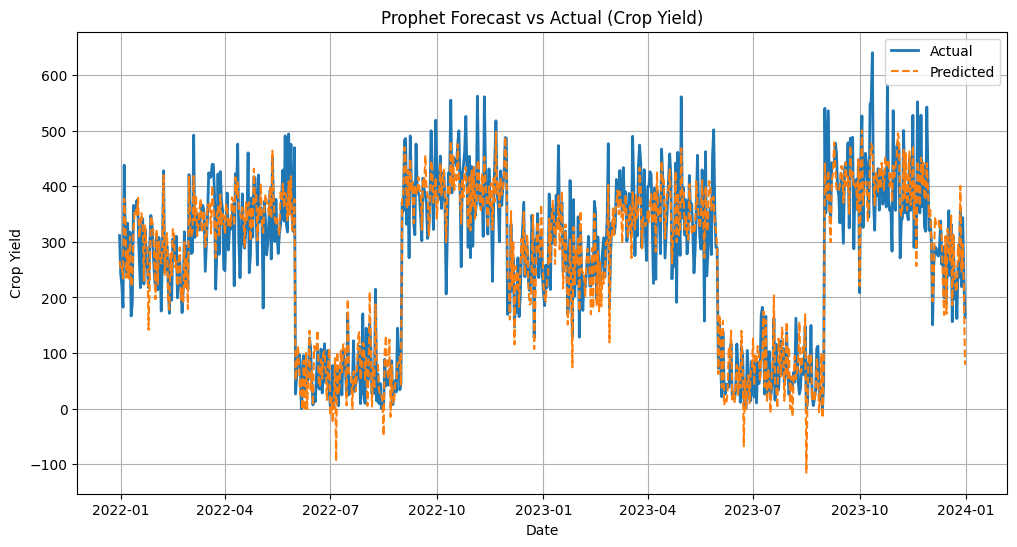

Prophet model saved as 'prophet_model.pkl'


In [11]:
#correct prophet code:
# -------------------------------
# STEP 1: Import libraries
# -------------------------------
import pandas as pd
from prophet import Prophet
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np
import matplotlib.pyplot as plt
import joblib  # for saving/loading model

# -------------------------------
# STEP 2: Load dataset
# -------------------------------
df = pd.read_csv(
    "/kaggle/input/crop-yield-and-environmental-factors-2014-2023/crop_yield_dataset.csv",
    parse_dates=['Date']
)

# -------------------------------
# STEP 3: Aggregate daily (sum/mean)
# -------------------------------
df_daily = df.groupby('Date').agg({
    'Crop_Yield': 'sum',          # total yield per day
    'Temperature': 'mean',
    'Humidity': 'mean',
    'Wind_Speed': 'mean',
    'Soil_pH': 'mean',
    'N': 'mean',
    'P': 'mean',
    'K': 'mean',
    'Soil_Quality': 'mean'
}).sort_index()

# Ensure daily frequency and fill missing values
df_daily = df_daily.asfreq('D').fillna(method='ffill')

# -------------------------------
# STEP 4: Prepare data for Prophet
# -------------------------------
data = df_daily.reset_index().rename(columns={'Date': 'ds', 'Crop_Yield': 'y'})

# Numeric regressors
regressors = ['Temperature', 'Humidity', 'Wind_Speed', 'Soil_pH', 'N', 'P', 'K', 'Soil_Quality']

# -------------------------------
# STEP 5: Train-test split
# -------------------------------
split = int(len(data) * 0.8)
train_df = data.iloc[:split].copy()
test_df = data.iloc[split:].copy()

# -------------------------------
# STEP 6: Initialize Prophet and add regressors
# -------------------------------
model = Prophet()

for reg in regressors:
    model.add_regressor(reg)

# Fit the model
model.fit(train_df)

# -------------------------------
# STEP 7: Make predictions
# -------------------------------
# Ensure no NaNs in test regressors
future = test_df.copy()
future[regressors] = future[regressors].fillna(method='ffill')

forecast = model.predict(future)

# Extract predictions
y_pred = forecast['yhat'].values
y_test = test_df['y'].values

# -------------------------------
# STEP 8: Evaluate performance
# -------------------------------
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

# Safe MAPE (ignore zeros)
y_test_nonzero = y_test[y_test != 0]
y_pred_nonzero = y_pred[y_test != 0]
mape_safe = np.mean(np.abs((y_test_nonzero - y_pred_nonzero) / y_test_nonzero)) * 100

print(f"MSE: {mse:.2f}")
print(f"R²: {r2:.3f}")
print(f"MAPE (ignoring zeros): {mape_safe:.2f}%")

# -------------------------------
# STEP 9: Plot actual vs predicted
# -------------------------------
plt.figure(figsize=(12,6))
plt.plot(test_df['ds'], y_test, label='Actual', linewidth=2)
plt.plot(test_df['ds'], y_pred, label='Predicted', linestyle='--')
plt.title('Prophet Forecast vs Actual (Crop Yield)')
plt.xlabel('Date')
plt.ylabel('Crop Yield')
plt.legend()
plt.grid(True)
plt.show()

# -------------------------------
# STEP 10: Save model using pickle
# -------------------------------
joblib.dump(model, 'prophet_model.pkl')
print("Prophet model saved as 'prophet_model.pkl'")

# -------------------------------
# STEP 11: Load model later
# -------------------------------
# loaded_model = joblib.load('prophet_model.pkl')
# future_loaded = test_df.copy()
# future_loaded[regressors] = future_loaded[regressors].fillna(method='ffill')
# forecast_loaded = loaded_model.predict(future_loaded)
# print("Prophet model loaded and predictions done!")


In [12]:
#prophet code for each crop
# -------------------------------
# STEP 1: Import libraries
# -------------------------------
import pandas as pd
from prophet import Prophet
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np
import matplotlib.pyplot as plt
import joblib  # for saving/loading models
import os

# -------------------------------
# STEP 2: Load dataset
# -------------------------------
df = pd.read_csv(
    "/kaggle/input/crop-yield-and-environmental-factors-2014-2023/crop_yield_dataset.csv",
    parse_dates=['Date']
)

# Check if 'Crop_Type' column exists
if 'Crop_Type' not in df.columns:
    raise ValueError("Dataset must have a 'Crop_Type' column for separate crop models.")

# -------------------------------
# STEP 3: Create folder to save models
# -------------------------------
model_dir = "models/prophet"
os.makedirs(model_dir, exist_ok=True)

# -------------------------------
# STEP 4: Define regressors
# -------------------------------
regressors = ['Temperature', 'Humidity', 'Wind_Speed', 'Soil_pH', 'N', 'P', 'K', 'Soil_Quality']

# -------------------------------
# STEP 5: Train separate Prophet models per crop
# -------------------------------
crops = df['Crop_Type'].unique()

for crop in crops:
    print(f"\nTraining model for crop: {crop}")

    # Filter data for this crop
    df_crop = df[df['Crop_Type'] == crop].copy()

    # Aggregate daily
    df_daily = df_crop.groupby('Date').agg({
        'Crop_Yield': 'sum',  # or 'mean' if preferred
        'Temperature': 'mean',
        'Humidity': 'mean',
        'Wind_Speed': 'mean',
        'Soil_pH': 'mean',
        'N': 'mean',
        'P': 'mean',
        'K': 'mean',
        'Soil_Quality': 'mean'
    }).sort_index()

    # Fill missing dates
    df_daily = df_daily.asfreq('D').fillna(method='ffill')

    # Prepare data for Prophet
    data = df_daily.reset_index().rename(columns={'Date': 'ds', 'Crop_Yield': 'y'})

    # Train-test split
    split = int(len(data) * 0.8)
    train_df = data.iloc[:split].copy()
    test_df = data.iloc[split:].copy()

    # Initialize Prophet and add regressors
    model = Prophet()
    for reg in regressors:
        model.add_regressor(reg)

    # Fit the model
    model.fit(train_df)

    # Predict on test set for evaluation
    future = test_df.copy()
    future[regressors] = future[regressors].fillna(method='ffill')
    forecast = model.predict(future)

    y_pred = forecast['yhat'].values
    y_test = test_df['y'].values

    # Evaluate
    mse = mean_squared_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    y_test_nonzero = y_test[y_test != 0]
    y_pred_nonzero = y_pred[y_test != 0]
    mape_safe = np.mean(np.abs((y_test_nonzero - y_pred_nonzero) / y_test_nonzero)) * 100

    print(f"MSE: {mse:.2f}, R²: {r2:.3f}, MAPE: {mape_safe:.2f}%")

    # Save the model for this crop
    model_filename = os.path.join(model_dir, f"{crop.lower()}_prophet.pkl")
    joblib.dump(model, model_filename)
    print(f"Prophet model saved for {crop} at {model_filename}")

print("\nAll crop models trained and saved successfully!")


/tmp/ipykernel_39/1489683798.py:61: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df_daily = df_daily.asfreq('D').fillna(method='ffill')
13:19:16 - cmdstanpy - INFO - Chain [1] start processing



Training model for crop: Wheat


13:19:16 - cmdstanpy - INFO - Chain [1] done processing
/tmp/ipykernel_39/1489683798.py:81: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  future[regressors] = future[regressors].fillna(method='ffill')
/tmp/ipykernel_39/1489683798.py:61: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df_daily = df_daily.asfreq('D').fillna(method='ffill')
13:19:17 - cmdstanpy - INFO - Chain [1] start processing


MSE: 147.52, R²: 0.762, MAPE: 131.72%
Prophet model saved for Wheat at models/prophet/wheat_prophet.pkl

Training model for crop: Corn


13:19:17 - cmdstanpy - INFO - Chain [1] done processing
/tmp/ipykernel_39/1489683798.py:81: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  future[regressors] = future[regressors].fillna(method='ffill')
/tmp/ipykernel_39/1489683798.py:61: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df_daily = df_daily.asfreq('D').fillna(method='ffill')
13:19:17 - cmdstanpy - INFO - Chain [1] start processing


...

MSE: 221.73, R²: 0.574, MAPE: 148.73%
Prophet model saved for Tomato at models/prophet/tomato_prophet.pkl

Training model for crop: Potato


13:19:21 - cmdstanpy - INFO - Chain [1] done processing
/tmp/ipykernel_39/1489683798.py:81: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  future[regressors] = future[regressors].fillna(method='ffill')
/tmp/ipykernel_39/1489683798.py:61: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df_daily = df_daily.asfreq('D').fillna(method='ffill')
13:19:22 - cmdstanpy - INFO - Chain [1] start processing


MSE: 117.81, R²: 0.795, MAPE: 67.47%
Prophet model saved for Potato at models/prophet/potato_prophet.pkl

Training model for crop: Sunflower


13:19:22 - cmdstanpy - INFO - Chain [1] done processing
/tmp/ipykernel_39/1489683798.py:81: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  future[regressors] = future[regressors].fillna(method='ffill')


MSE: 154.57, R²: 0.782, MAPE: 80.80%
Prophet model saved for Sunflower at models/prophet/sunflower_prophet.pkl

All crop models trained and saved successfully!
